# Кластеризация данных физической активности

В этом ноутбуке решается задача кластеризации сенсорных данных (IMU-сенсоров) и формируется `submission.csv` для Kaggle-соревнования **Clustering Physical Activity Data**.

План работы:
- загрузка и первичный анализ данных;
- предобработка и подготовка признаков;
- обучение нескольких алгоритмов кластеризации;
- выбор лучшей модели по внутренним метрикам;
- интерпретация кластеров и преобразование их в `activityID`;
- подготовка итогового файла для отправки.


In [1]:
# Если каких-то пакетов нет в окружении, ячейка их поставит
%pip -q install numpy pandas scikit-learn matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set(style='whitegrid', context='notebook')


## 1. Загрузка данных


In [3]:
DATA_PATH = 'data/Physical_Activity_Monitoring_unlabeled.csv'

df = pd.read_csv(DATA_PATH)
print('Размер датасета:', df.shape)
print('Количество признаков:', df.shape[1])
display(df.head())


Размер датасета: (534601, 53)
Количество признаков: 53


,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,252.75,34.8750,0.902847,7.45872,6.032490,1.006100,7.44575,6.303650,-0.021952,0.004114,...,-0.025606,0.030239,-14.5447,27.3336,-5.76620,0.206416,0.348212,0.763201,-0.503652,5
1,3652.45,29.7500,-4.069330,3.76168,8.279720,-5.972500,3.22273,6.908970,0.116054,-0.375968,...,-0.670163,1.786200,-32.8257,-15.7719,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2
2,504.76,34.3750,-2.007540,-9.60180,0.773674,-1.803500,-9.58937,1.073680,0.020131,0.042189,...,-0.009741,-0.006579,-18.8171,16.3089,25.29280,0.139776,0.676586,0.393796,0.606316,8
3,2801.61,31.9375,-13.262200,5.85443,0.899334,-13.611500,5.91511,0.840377,1.715630,-0.050492,...,-0.163470,-3.495570,-26.7418,34.3566,21.32740,0.416303,0.783387,0.306464,0.345075,2
4,441.01,33.5000,-0.013940,8.66540,4.398210,0.144153,8.56816,4.822200,-0.006938,-0.007383,...,-0.028172,-0.003737,-17.7798,-3.9981,10.99500,0.171133,-0.748343,0.252988,-0.588807,6


In [5]:
print('Информация по типам и пропускам:')
df.info()

missing = df.isna().mean().sort_values(ascending=False)
print('Топ-10 признаков по доле пропусков:')
display((missing.head(10) * 100).round(3).to_frame('missing_%'))


Информация по типам и пропускам:
<class 'pandas.DataFrame'>
RangeIndex: 534601 entries, 0 to 534600
Data columns (total 53 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          534601 non-null  float64
 1   handTemperature    530560 non-null  float64
 2   handAcc16_1        530560 non-null  float64
 3   handAcc16_2        530560 non-null  float64
 4   handAcc16_3        530560 non-null  float64
 5   handAcc6_1         530560 non-null  float64
 6   handAcc6_2         530560 non-null  float64
 7   handAcc6_3         530560 non-null  float64
 8   handGyro1          530560 non-null  float64
 9   handGyro2          530560 non-null  float64
 10  handGyro3          530560 non-null  float64
 11  handMagne1         530560 non-null  float64
 12  handMagne2         530560 non-null  float64
 13  handMagne3         530560 non-null  float64
 14  handOrientation1   530560 non-null  float64
 15  handOrientation2   530560 non

,missing_%
handOrientation4,0.756
handGyro2,0.756
handOrientation3,0.756
handOrientation2,0.756
handOrientation1,0.756
handMagne3,0.756
handMagne1,0.756
handGyro3,0.756
handMagne2,0.756
handGyro1,0.756


## 2. Краткий EDA

Смотрим несколько базовых распределений температур по сенсорам.


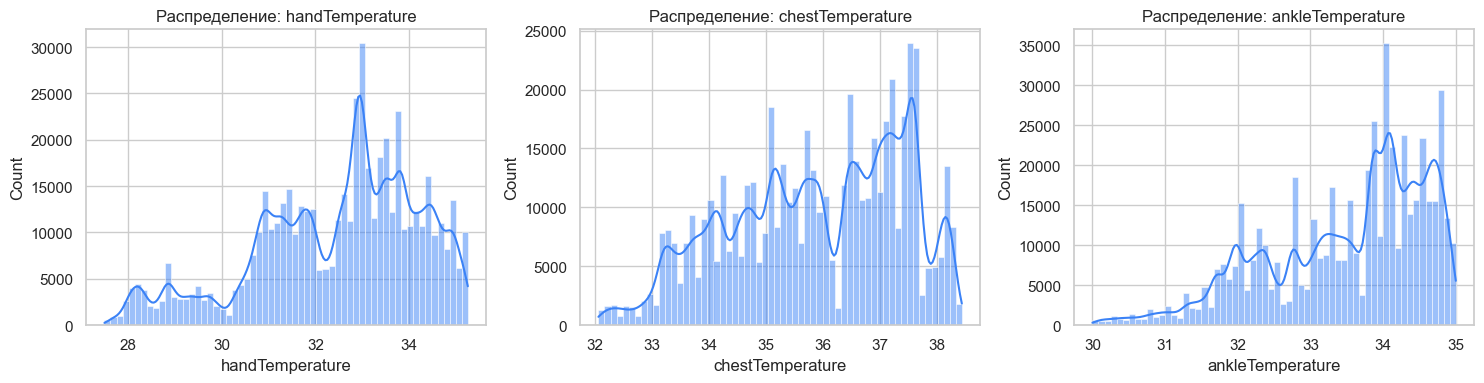

In [6]:
eda_cols = ['handTemperature', 'chestTemperature', 'ankleTemperature']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes.ravel(), eda_cols):
    sns.histplot(df[col], bins=60, kde=True, ax=ax, color='#3b82f6')
    ax.set_title(f'Распределение: {col}')
plt.tight_layout()
plt.show()


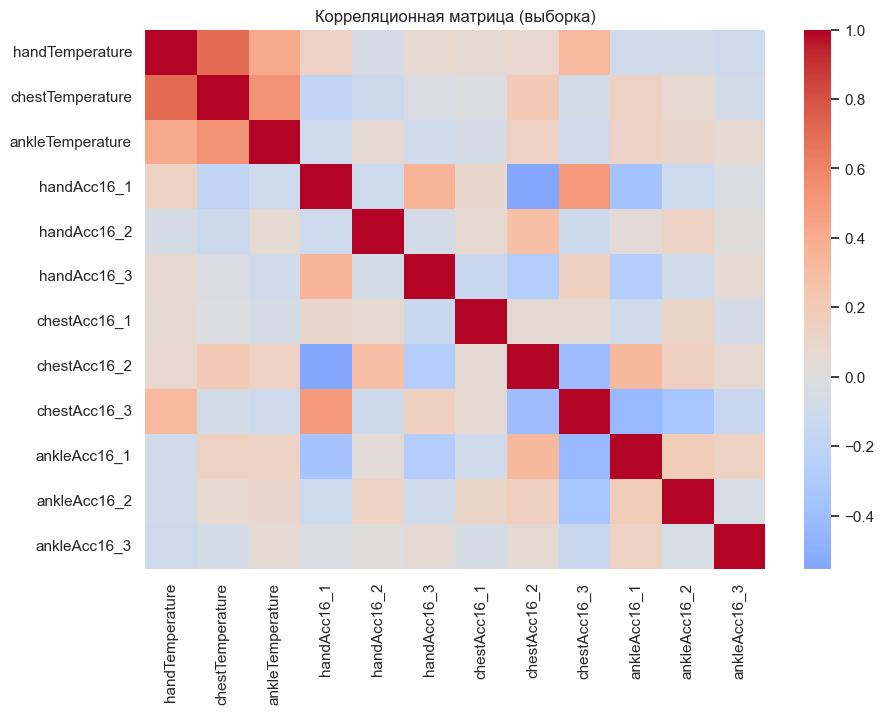

In [7]:
# Корреляции посмотрим на небольшом случайном подмножестве
sample_corr = df.sample(min(25000, len(df)), random_state=RANDOM_STATE)
corr_cols = ['handTemperature', 'chestTemperature', 'ankleTemperature',
             'handAcc16_1', 'handAcc16_2', 'handAcc16_3',
             'chestAcc16_1', 'chestAcc16_2', 'chestAcc16_3',
             'ankleAcc16_1', 'ankleAcc16_2', 'ankleAcc16_3']

plt.figure(figsize=(10, 7))
sns.heatmap(sample_corr[corr_cols].corr(), cmap='coolwarm', center=0)
plt.title('Корреляционная матрица (выборка)')
plt.show()


## 3. Предобработка

Что делаем:
- удаляем технические поля `timestamp`, `subject_id` (не должны определять тип активности напрямую);
- заменяем пропуски медианами;
- стандартизируем признаки;
- уменьшаем размерность через PCA (сохраняем 95% дисперсии).


In [8]:
drop_cols = ['timestamp', 'subject_id']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()

# Медианная импутация
X = X.fillna(X.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print('Исходная размерность:', X.shape[1])
print('Размерность после PCA:', X_pca.shape[1])
print('Объясненная дисперсия:', round(pca.explained_variance_ratio_.sum(), 4))


Исходная размерность: 51
Размерность после PCA: 32
Объясненная дисперсия: 0.9548


## 4. Подбор алгоритма кластеризации

Так как в соревновании требуется 8 классов активности, сравниваем модели при `n_clusters=8`.

Сравнение проводим на подвыборке, чтобы ускорить расчет внутренних метрик.


In [9]:
K = 8

idx = np.random.choice(len(X_pca), size=min(120000, len(X_pca)), replace=False)
X_eval = X_pca[idx]

models = {
    'MiniBatchKMeans': MiniBatchKMeans(n_clusters=K, random_state=RANDOM_STATE, batch_size=4096, n_init=20),
    'GaussianMixture': GaussianMixture(n_components=K, covariance_type='diag', random_state=RANDOM_STATE),
    'Birch': Birch(n_clusters=K, threshold=0.5)
}

rows = []
for name, model in models.items():
    labels = model.fit_predict(X_eval)
    rows.append({
        'model': name,
        'silhouette': silhouette_score(X_eval, labels),
        'davies_bouldin': davies_bouldin_score(X_eval, labels),
        'calinski_harabasz': calinski_harabasz_score(X_eval, labels)
    })

metrics_df = pd.DataFrame(rows).sort_values(['silhouette', 'calinski_harabasz'], ascending=[False, False])
display(metrics_df)


,model,silhouette,davies_bouldin,calinski_harabasz
0,MiniBatchKMeans,0.148076,2.206534,8841.664758
2,Birch,0.071540,2.464687,4732.545057
1,GaussianMixture,0.066372,3.543848,6098.356617


In [10]:
# Выбираем модель по silhouette (чем больше, тем лучше)
best_name = metrics_df.iloc[0]['model']
print('Лучшая модель по метрикам:', best_name)

if best_name == 'MiniBatchKMeans':
    best_model = MiniBatchKMeans(n_clusters=K, random_state=RANDOM_STATE, batch_size=4096, n_init=30)
elif best_name == 'GaussianMixture':
    best_model = GaussianMixture(n_components=K, covariance_type='diag', random_state=RANDOM_STATE)
else:
    best_model = Birch(n_clusters=K, threshold=0.5)

cluster_raw = best_model.fit_predict(X_pca)
df['cluster_raw'] = cluster_raw

print('Кластеры построены. Распределение объектов по кластерам:')
display(df['cluster_raw'].value_counts().sort_index().to_frame('count'))


Лучшая модель по метрикам: MiniBatchKMeans
Кластеры построены. Распределение объектов по кластерам:


,count
cluster_raw,
0,54239
1,101116
2,87764
3,66801
4,95882
5,70753
6,50405
7,7641


## 5. Интерпретация кластеров и перевод в `activityID`

В данных нет истинных меток активности, поэтому делаем практичный эвристический маппинг:
- считаем агрегированный «уровень движения» из ускорений (по 3 IMU-модулям);
- используем также температуры модулей как слабый дополнительный признак;
- сортируем кластеры по итоговому activity-score и присваиваем ID от 1 до 8.

Это не гарантирует идеального соответствия реальным именам активностей, но дает воспроизводимый и объяснимый способ нумерации для submission.


In [11]:
def acc_norm(df_part, prefix):
    return np.sqrt(
        df_part[f'{prefix}Acc16_1']**2 +
        df_part[f'{prefix}Acc16_2']**2 +
        df_part[f'{prefix}Acc16_3']**2
    )

tmp = df.copy()
tmp['hand_acc_norm'] = acc_norm(tmp, 'hand')
tmp['chest_acc_norm'] = acc_norm(tmp, 'chest')
tmp['ankle_acc_norm'] = acc_norm(tmp, 'ankle')

profile = tmp.groupby('cluster_raw')[['hand_acc_norm', 'chest_acc_norm', 'ankle_acc_norm', 'handTemperature', 'chestTemperature', 'ankleTemperature']].mean()

# activity_score: взвешенная сумма нормализованных средних
z_profile = (profile - profile.mean()) / profile.std(ddof=0)
profile['activity_score'] = (
    0.35 * z_profile['hand_acc_norm'] +
    0.35 * z_profile['chest_acc_norm'] +
    0.20 * z_profile['ankle_acc_norm'] +
    0.10 * z_profile[['handTemperature', 'chestTemperature', 'ankleTemperature']].mean(axis=1)
)

profile = profile.sort_values('activity_score')
profile['activityID'] = np.arange(1, len(profile) + 1)

cluster_to_activity = profile['activityID'].to_dict()
df['activityID'] = df['cluster_raw'].map(cluster_to_activity).astype(int)

display(profile)
print('Маппинг cluster -> activityID:', cluster_to_activity)


,hand_acc_norm,chest_acc_norm,ankle_acc_norm,handTemperature,chestTemperature,ankleTemperature,activity_score,activityID
cluster_raw,,,,,,,,
2,9.724616,9.544842,10.178548,32.760135,35.140560,33.007416,-0.613908,1
5,9.946917,9.932972,10.205050,33.021000,35.550040,33.540425,-0.486069,2
0,10.801272,9.745952,12.088431,30.556445,35.255045,33.053154,-0.432438,3
3,10.363097,9.916047,10.808746,33.072670,36.281424,33.535865,-0.378092,4
6,10.516067,9.689364,13.250095,32.206844,35.202929,33.551676,-0.208342,5
1,11.163264,9.965823,13.762165,32.497986,36.518017,33.813682,-0.016563,6
4,11.673519,10.191600,14.338924,32.619559,36.626297,33.758204,0.076880,7
7,46.475047,25.106813,15.635097,30.490992,34.294221,33.442329,2.058531,8


Маппинг cluster -> activityID: {2: 1, 5: 2, 0: 3, 3: 4, 6: 5, 1: 6, 4: 7, 7: 8}


## 6. Формирование submission

Формат из соревнования:
- колонки: `index,activityID`;
- без дополнительного заголовка/информации.


In [12]:
submission = pd.DataFrame({
    'index': np.arange(len(df)),
    'activityID': df['activityID'].astype(int)
})

submission.to_csv('submission.csv', index=False)
profile.to_csv('cluster_profile.csv')

display(submission.head())
print('Файл сохранен: submission.csv')
print('Дополнительно сохранен: cluster_profile.csv')


,index,activityID
0,0,1
1,1,3
2,2,6
3,3,6
4,4,2


Файл сохранен: submission.csv
Дополнительно сохранен: cluster_profile.csv


## 7. Вывод

Сделана полная цепочка для задания:
- исследованы данные и проверены пропуски;
- выполнены нормализация и снижение размерности;
- сравнены несколько алгоритмов кластеризации;
- построен воспроизводимый маппинг кластеров в `activityID`;
- подготовлен `submission.csv` для отправки на Kaggle.

Для улучшения результата можно отдельно поиграть с:
- числом компонент PCA (например, 0.90 / 0.97);
- гиперпараметрами `MiniBatchKMeans`;
- формулой `activity_score` при маппинге кластеров.
